**Table of contents**<a id='toc0_'></a>    
- [文件说明（File descriptions）](#toc1_)    
- [数据字段（Data fields）](#toc2_)    
- [导入库](#toc3_)    
- [EDA(数据探索性分析)](#toc4_)    
- [工具函数](#toc5_)    
- [数据预处理](#toc6_)    
- [特征工程](#toc7_)    
- [贝叶斯优化参数空间](#toc8_)     
- [5 折交叉验证训练](#toc10_)    
- [模型融合](#toc11_)    
  - [加权融合（权重按 OOF F1 的幂次）](#toc11_1_)    
  - [Stacking（Logistic/RandomForest 选最佳）](#toc11_2_)    
- [提交文件](#toc12_)    
- [结果可视化](#toc13_)    

<!-- vscode-jupyter-toc-config
    numbering=false
    anchor=true
    flat=false
    minLevel=1
    maxLevel=6
    /vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a> 文件说明（File descriptions）

* **cde_ipaas_dataset.csv** - 包含 IoT 传感器在云端传输过程中的查询配置、数据特征、能效指标及传输性能数据。

# <a id='toc2_'></a> 数据字段（Data fields）

* **query_id** - 查询 ID（每次数据传输任务的唯一标识符）
* **sensor_type** - 传感器类型（采集数据的设备类型，如 "PulseOximeter" 脉搏血氧仪、"BloodPressure" 血压计等）
* **data_size_bytes** - 数据大小（单次传输的数据载荷大小，单位：字节）
* **quantity** - 数量（在单次观测任务中采集或传输的数据点数量）
* **duration** - 时长（完成数据传输任务所需的时间，单位：毫秒/秒）
* **energy_consumption** - 能耗（执行该传输任务所消耗的能量，单位：焦耳/J）
* **data_yield** - 数据收益/产出（单位能量或单位时间内有效传输的数据量指标）
* **hypervolume_value** - 超体积值（用于评估多目标优化性能的指标，反映了传输方案在带宽、延迟和功耗之间的平衡性）
* **transmission_efficiency** - **传输效率（衡量数据传输质量与资源消耗比率的核心指标）** <font color="red">**(Target / 预测目标)**</font>

# <a id='toc3_'></a>[导入库](#toc0_)

In [1]:
# ==========================================
# 数据传输效率预测 (LightGBM + XGBoost + CatBoost)
# 1. 自动贝叶斯优化（LGB/XGB/CAT）
# 2. 五折 KFold 训练
# 3. 加权融合 + Stacking
# 4. SHAP 解释性 + ROC/PR 可视化
# ==========================================
import warnings, os, random, gc, re
warnings.filterwarnings('ignore')
import matplotlib as mpl

# 设置全局字体，支持中文显示
# ----------------------------
# 解决中文字体 & findfont 报错
# ----------------------------
# 让 matplotlib 走 “sans-serif 字体族”
mpl.rcParams["font.family"] = "sans-serif"

# 让中文字体排在最前（有哪个用哪个）
mpl.rcParams["font.sans-serif"] = [
    "Noto Sans CJK SC",      # 你装了 fonts-noto-cjk 后通常就有
    "WenQuanYi Zen Hei",     # fonts-wqy-zenhei
    "WenQuanYi Micro Hei",   # fonts-wqy-microhei
    "SimHei",                # 万一你后来自己装了 SimHei
    "Microsoft YaHei",
    "Arial Unicode MS",
    "DejaVu Sans",           # 最后兜底（不保证中文）
]

# 负号正常显示
mpl.rcParams["axes.unicode_minus"] = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import shap
shap.initjs()

from skopt import BayesSearchCV
from skopt.space import Real, Integer

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

# <a id='toc4_'></a>[EDA(数据探索性分析)](#toc0_)

1. 查看表格数据全貌​
2. 分析数据特征类型与缺失值情况​
3. 探究类别特征与目标特征的关联关系​
4. 剖析数值特征的数据分布特征

In [2]:
TRAIN_PATH = "cde_ipaas_dataset.csv"
SUBMISSION_OUT = "submission.csv"

In [3]:
# ------------------------------------------------------------------
# 读取数据
# ------------------------------------------------------------------
data = pd.read_csv(TRAIN_PATH)
train, test = train_test_split(data, test_size=0.2, random_state=42)
train_data = train.copy()

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 9254 to 7270
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   query_id                 8000 non-null   int64  
 1   sensor_type              8000 non-null   object 
 2   data_size_bytes          8000 non-null   int64  
 3   quantity                 8000 non-null   int64  
 4   duration                 8000 non-null   int64  
 5   energy_consumption       8000 non-null   float64
 6   data_yield               8000 non-null   float64
 7   hypervolume_value        8000 non-null   float64
 8   transmission_efficiency  8000 non-null   float64
dtypes: float64(4), int64(4), object(1)
memory usage: 625.0+ KB


In [5]:
print(train.isnull().sum()) #checking for total null values

query_id                   0
sensor_type                0
data_size_bytes            0
quantity                   0
duration                   0
energy_consumption         0
data_yield                 0
hypervolume_value          0
transmission_efficiency    0
dtype: int64


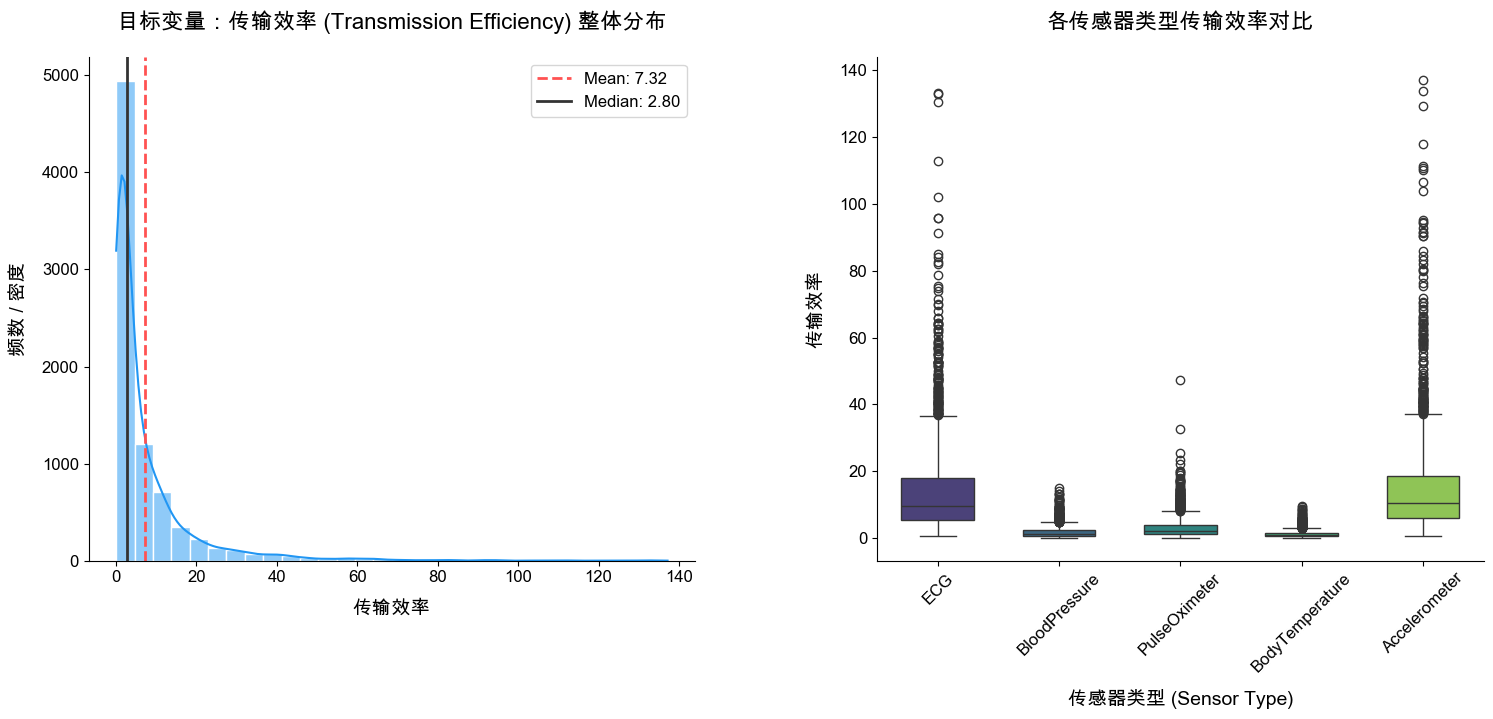

In [6]:
# 确保目标变量是数值型（新目标：transmission_efficiency）
train_data['transmission_efficiency'] = pd.to_numeric(train_data['transmission_efficiency'], errors='coerce')

# 创建画布和子图，调整间距
f, ax = plt.subplots(1, 2, figsize=(18, 8))
plt.subplots_adjust(wspace=0.3, bottom=0.25)  # 增加底部边距以容纳旋转后的标签

# 定义配色方案
color_main = '#2196F3'   # 科技蓝 (更符合 IoT 背景)
palette_sensor = 'viridis' # 传感器类型配色

# --- 左图：目标变量分布 (Histogram + KDE) ---
# 用于展示连续变量（传输效率）的分布形状
sns.histplot(
    data=train_data,
    x='transmission_efficiency',
    kde=True,          # 显示核密度估计曲线
    ax=ax[0],
    color=color_main,
    edgecolor='white',
    bins=30
)

# 添加均值和中位数参考线
mean_val = train_data['transmission_efficiency'].mean()
median_val = train_data['transmission_efficiency'].median()
ax[0].axvline(mean_val, color='#FF5252', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
ax[0].axvline(median_val, color='#333333', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
ax[0].legend(fontsize=12)

ax[0].set_title('目标变量：传输效率 (Transmission Efficiency) 整体分布', fontsize=16, pad=20, fontweight='bold')
ax[0].set_xlabel('传输效率', fontsize=14, labelpad=10)
ax[0].set_ylabel('频数 / 密度', fontsize=14, labelpad=10)

# --- 右图：各传感器类型传输效率箱线图 (Box Plot) ---
# 用于对比不同传感器类型下的传输效率分布
sns.boxplot(
    x='sensor_type',
    y='transmission_efficiency',
    data=train_data,
    ax=ax[1],
    palette=palette_sensor,
    width=0.6,
    hue='sensor_type'  # 显式设置 hue
)

# 移除图例（因为 x 轴已有标签）
if ax[1].get_legend() is not None:
    ax[1].get_legend().remove()

ax[1].set_title('各传感器类型传输效率对比', fontsize=16, pad=20, fontweight='bold')
ax[1].set_xlabel('传感器类型 (Sensor Type)', fontsize=14, labelpad=10)
ax[1].set_ylabel('传输效率', fontsize=14, labelpad=10)

# 旋转 x 轴标签，防止传感器名称重叠
ax[1].tick_params(axis='x', rotation=45)

# --- 通用美化 ---
for axis in ax:
    # 美化刻度
    axis.tick_params(axis='both', which='major', labelsize=12)
    # 去除顶部和右侧边框
    for spine in axis.spines.values():
        if spine.spine_type in ['top', 'right']:
            spine.set_visible(False)

plt.show()

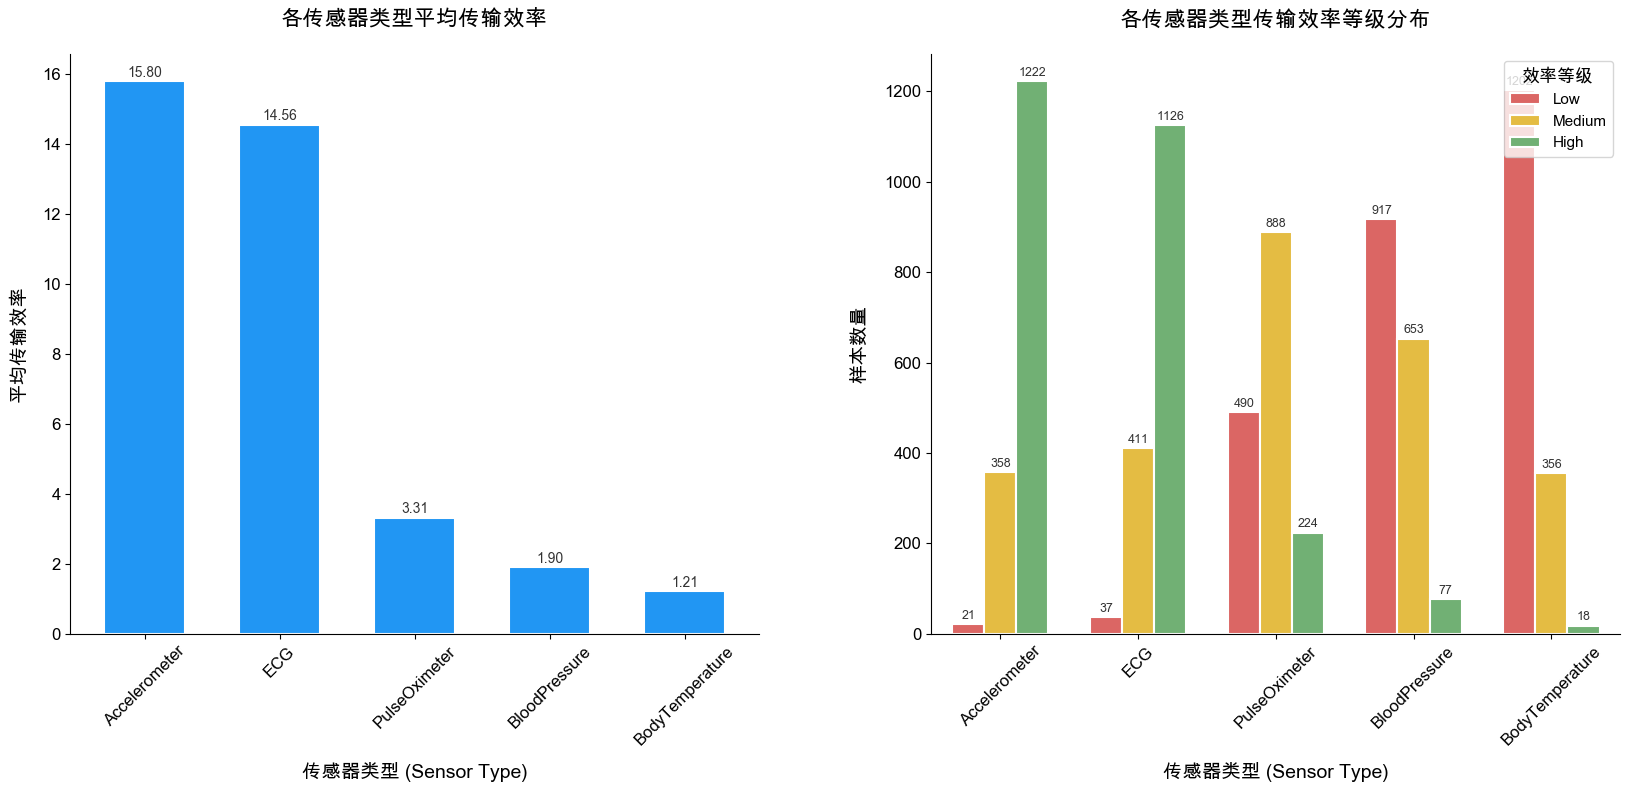

In [7]:
# 1. 使用 qcut 按分位数划分传输效率等级：Low (低), Medium (中), High (高)
# 针对 'transmission_efficiency' 进行划分
train_data['EfficiencyLevel'] = pd.qcut(train_data['transmission_efficiency'], q=3, labels=['Low', 'Medium', 'High'])

# 创建画布，调整子图间距
f, ax = plt.subplots(1, 2, figsize=(20, 10))
plt.subplots_adjust(wspace=0.25, bottom=0.3)

# 定义配色
mean_color = '#2196F3'  # 科技蓝用于均值柱状图
level_colors = ['#EF5350', '#FFCA28', '#66BB6A'] # 红/黄/绿 分别代表低/中/高效率等级

# --- 左侧：均值柱状图 (Mean Efficiency by SensorType) ---
# 计算每个传感器类型的平均传输效率
sensor_efficiency_mean = train_data[['sensor_type', 'transmission_efficiency']].groupby(['sensor_type']).mean()
# 按平均效率降序排列，使图表更整洁
sensor_efficiency_mean = sensor_efficiency_mean.sort_values(by='transmission_efficiency', ascending=False)

sensor_efficiency_mean.plot.bar(
    y='transmission_efficiency',
    ax=ax[0],
    color=mean_color,
    width=0.6,
    edgecolor='white',
    linewidth=1.5,
    legend=False
)
ax[0].set_title('各传感器类型平均传输效率', fontsize=16, pad=20, fontweight='bold')
ax[0].set_xlabel('传感器类型 (Sensor Type)', fontsize=14, labelpad=10)
ax[0].set_ylabel('平均传输效率', fontsize=14, labelpad=10)
# 旋转标签 45 度（传感器类型名称通常较短）
ax[0].tick_params(axis='x', labelsize=12, rotation=45)
ax[0].tick_params(axis='y', labelsize=12)

# 添加数值标签
for p in ax[0].patches:
    ax[0].text(
        p.get_x() + p.get_width()/2, p.get_height() + 0.05,
        f'{p.get_height():.2f}',
        ha='center', va='bottom', fontsize=10, color='#333333'
    )

# 去除左侧图边框
for spine in ax[0].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# --- 右侧：分组计数图 (Efficiency Level Distribution) ---
# order 参数保证右图的 x 轴顺序与左图一致
order = sensor_efficiency_mean.index

sns.countplot(
    x='sensor_type',
    hue='EfficiencyLevel',
    data=train_data,
    ax=ax[1],
    palette=level_colors,
    width=0.7,
    edgecolor='white',
    linewidth=1.5,
    order=order
)
ax[1].set_title('各传感器类型传输效率等级分布', fontsize=16, pad=20, fontweight='bold')
ax[1].set_xlabel('传感器类型 (Sensor Type)', fontsize=14, labelpad=10)
ax[1].set_ylabel('样本数量', fontsize=14, labelpad=10)
ax[1].tick_params(axis='x', labelsize=12, rotation=45)
ax[1].tick_params(axis='y', labelsize=12)

# 添加数值标签 (仅显示非零值)
for p in ax[1].patches:
    height = p.get_height()
    if height > 0:
        ax[1].text(
            p.get_x() + p.get_width()/2, height + 5,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=9, color='#333333'
        )

# 优化图例
ax[1].legend(title='效率等级', title_fontsize=13, fontsize=11, loc='upper right')

# 去除右侧图边框
for spine in ax[1].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

plt.show()

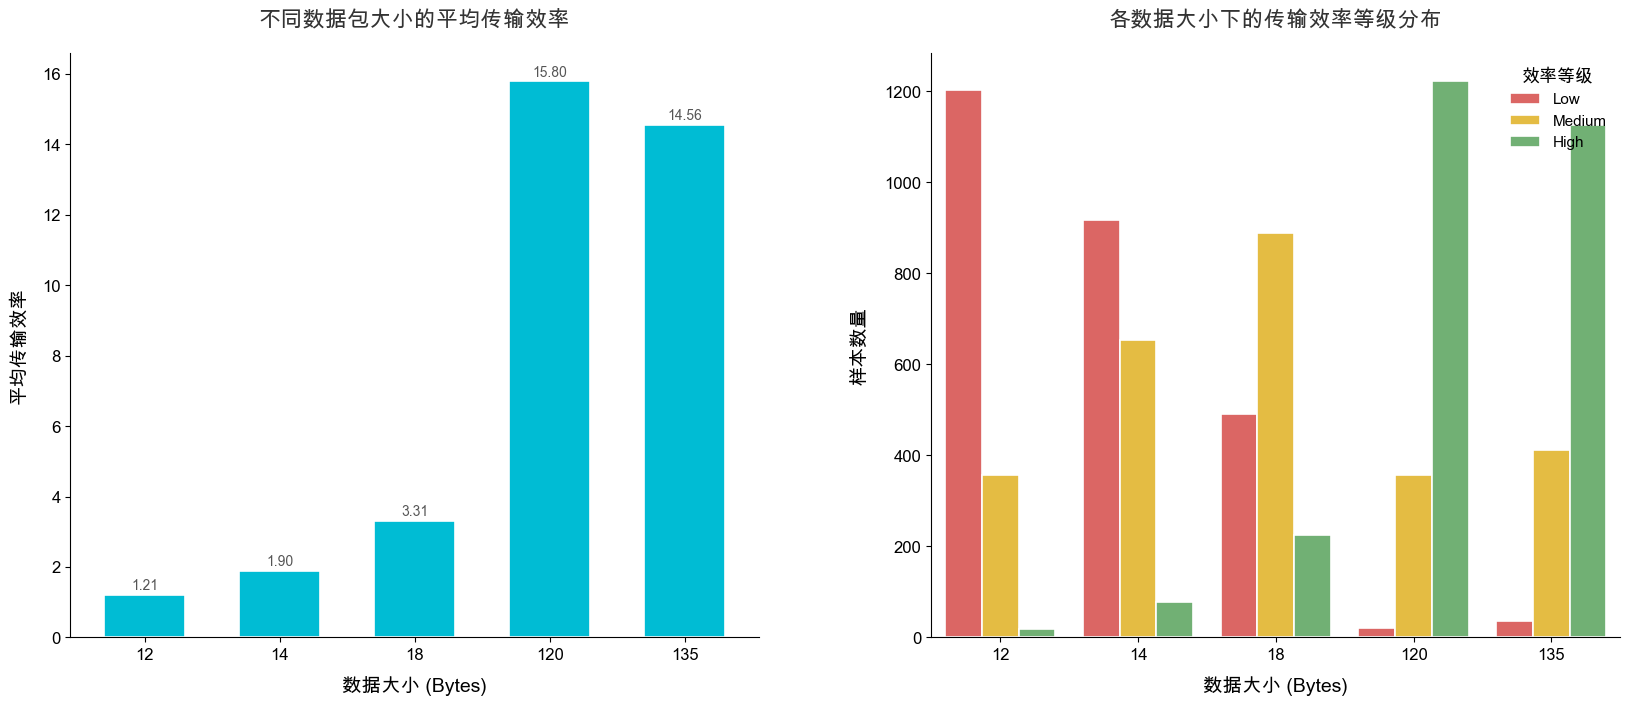

In [8]:
# 1. 预处理：创建传输效率等级
# 将传输效率离散化为三个等级用于右图分类展示 (Low/Medium/High)
train_data['EfficiencyLevel'] = pd.qcut(train_data['transmission_efficiency'], q=3, labels=['Low', 'Medium', 'High'])

# 获取唯一的数据大小并排序，确保图表 x 轴按从小到大排列
unique_sizes = sorted(train_data['data_size_bytes'].unique())

# 2. 创建画布并调整布局
f, ax = plt.subplots(1, 2, figsize=(20, 8))
plt.subplots_adjust(wspace=0.25, bottom=0.15) 

# 定义配色
mean_color = '#00BCD4'  # 青蓝色用于均值图
count_colors = ['#EF5350', '#FFCA28', '#66BB6A'] # 红/黄/绿 对应 低/中/高 效率

# --- 左侧：各数据大小平均传输效率 (Mean Efficiency vs Data Size) ---
# 计算每个数据大小的平均传输效率
size_mean = train_data[['data_size_bytes', 'transmission_efficiency']].groupby(['data_size_bytes']).mean()
# 确保排序
size_mean = size_mean.sort_index()

size_mean.plot.bar(
    y='transmission_efficiency',
    ax=ax[0],
    color=mean_color,
    width=0.6,
    edgecolor='white',
    linewidth=1.2,
    legend=False
)

# 左侧图标题与标签优化
ax[0].set_title('不同数据包大小的平均传输效率', fontsize=16, pad=20, fontweight='bold', color='#333333')
ax[0].set_xlabel('数据大小 (Bytes)', fontsize=14, labelpad=10)
ax[0].set_ylabel('平均传输效率', fontsize=14, labelpad=10)
ax[0].tick_params(axis='x', labelsize=12, rotation=0) # 数据量少，不需要大角度旋转
ax[0].tick_params(axis='y', labelsize=12)

# 添加数值标签 (保留2位小数)
for p in ax[0].patches:
    ax[0].text(
        p.get_x() + p.get_width()/2, p.get_height() + 0.05,
        f'{p.get_height():.2f}',
        ha='center', va='bottom', fontsize=10, color='#555555'
    )

# 去除边框
for spine in ax[0].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# --- 右侧：各数据大小下的效率等级分布 (Count Plot) ---
sns.countplot(
    x='data_size_bytes',
    hue='EfficiencyLevel',
    data=train_data,
    ax=ax[1],
    palette=count_colors,
    width=0.8,
    edgecolor='white',
    linewidth=1.2,
    order=unique_sizes
)

# 右侧图标题与标签优化
ax[1].set_title('各数据大小下的传输效率等级分布', fontsize=16, pad=20, fontweight='bold', color='#333333')
ax[1].set_xlabel('数据大小 (Bytes)', fontsize=14, labelpad=10)
ax[1].set_ylabel('样本数量', fontsize=14, labelpad=10)
ax[1].tick_params(axis='x', labelsize=12, rotation=0)
ax[1].tick_params(axis='y', labelsize=12)

# 优化图例
ax[1].legend(
    title='效率等级', 
    title_fontsize=13, 
    fontsize=11, 
    loc='upper right',
    frameon=False
)

# 去除边框
for spine in ax[1].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

plt.show()

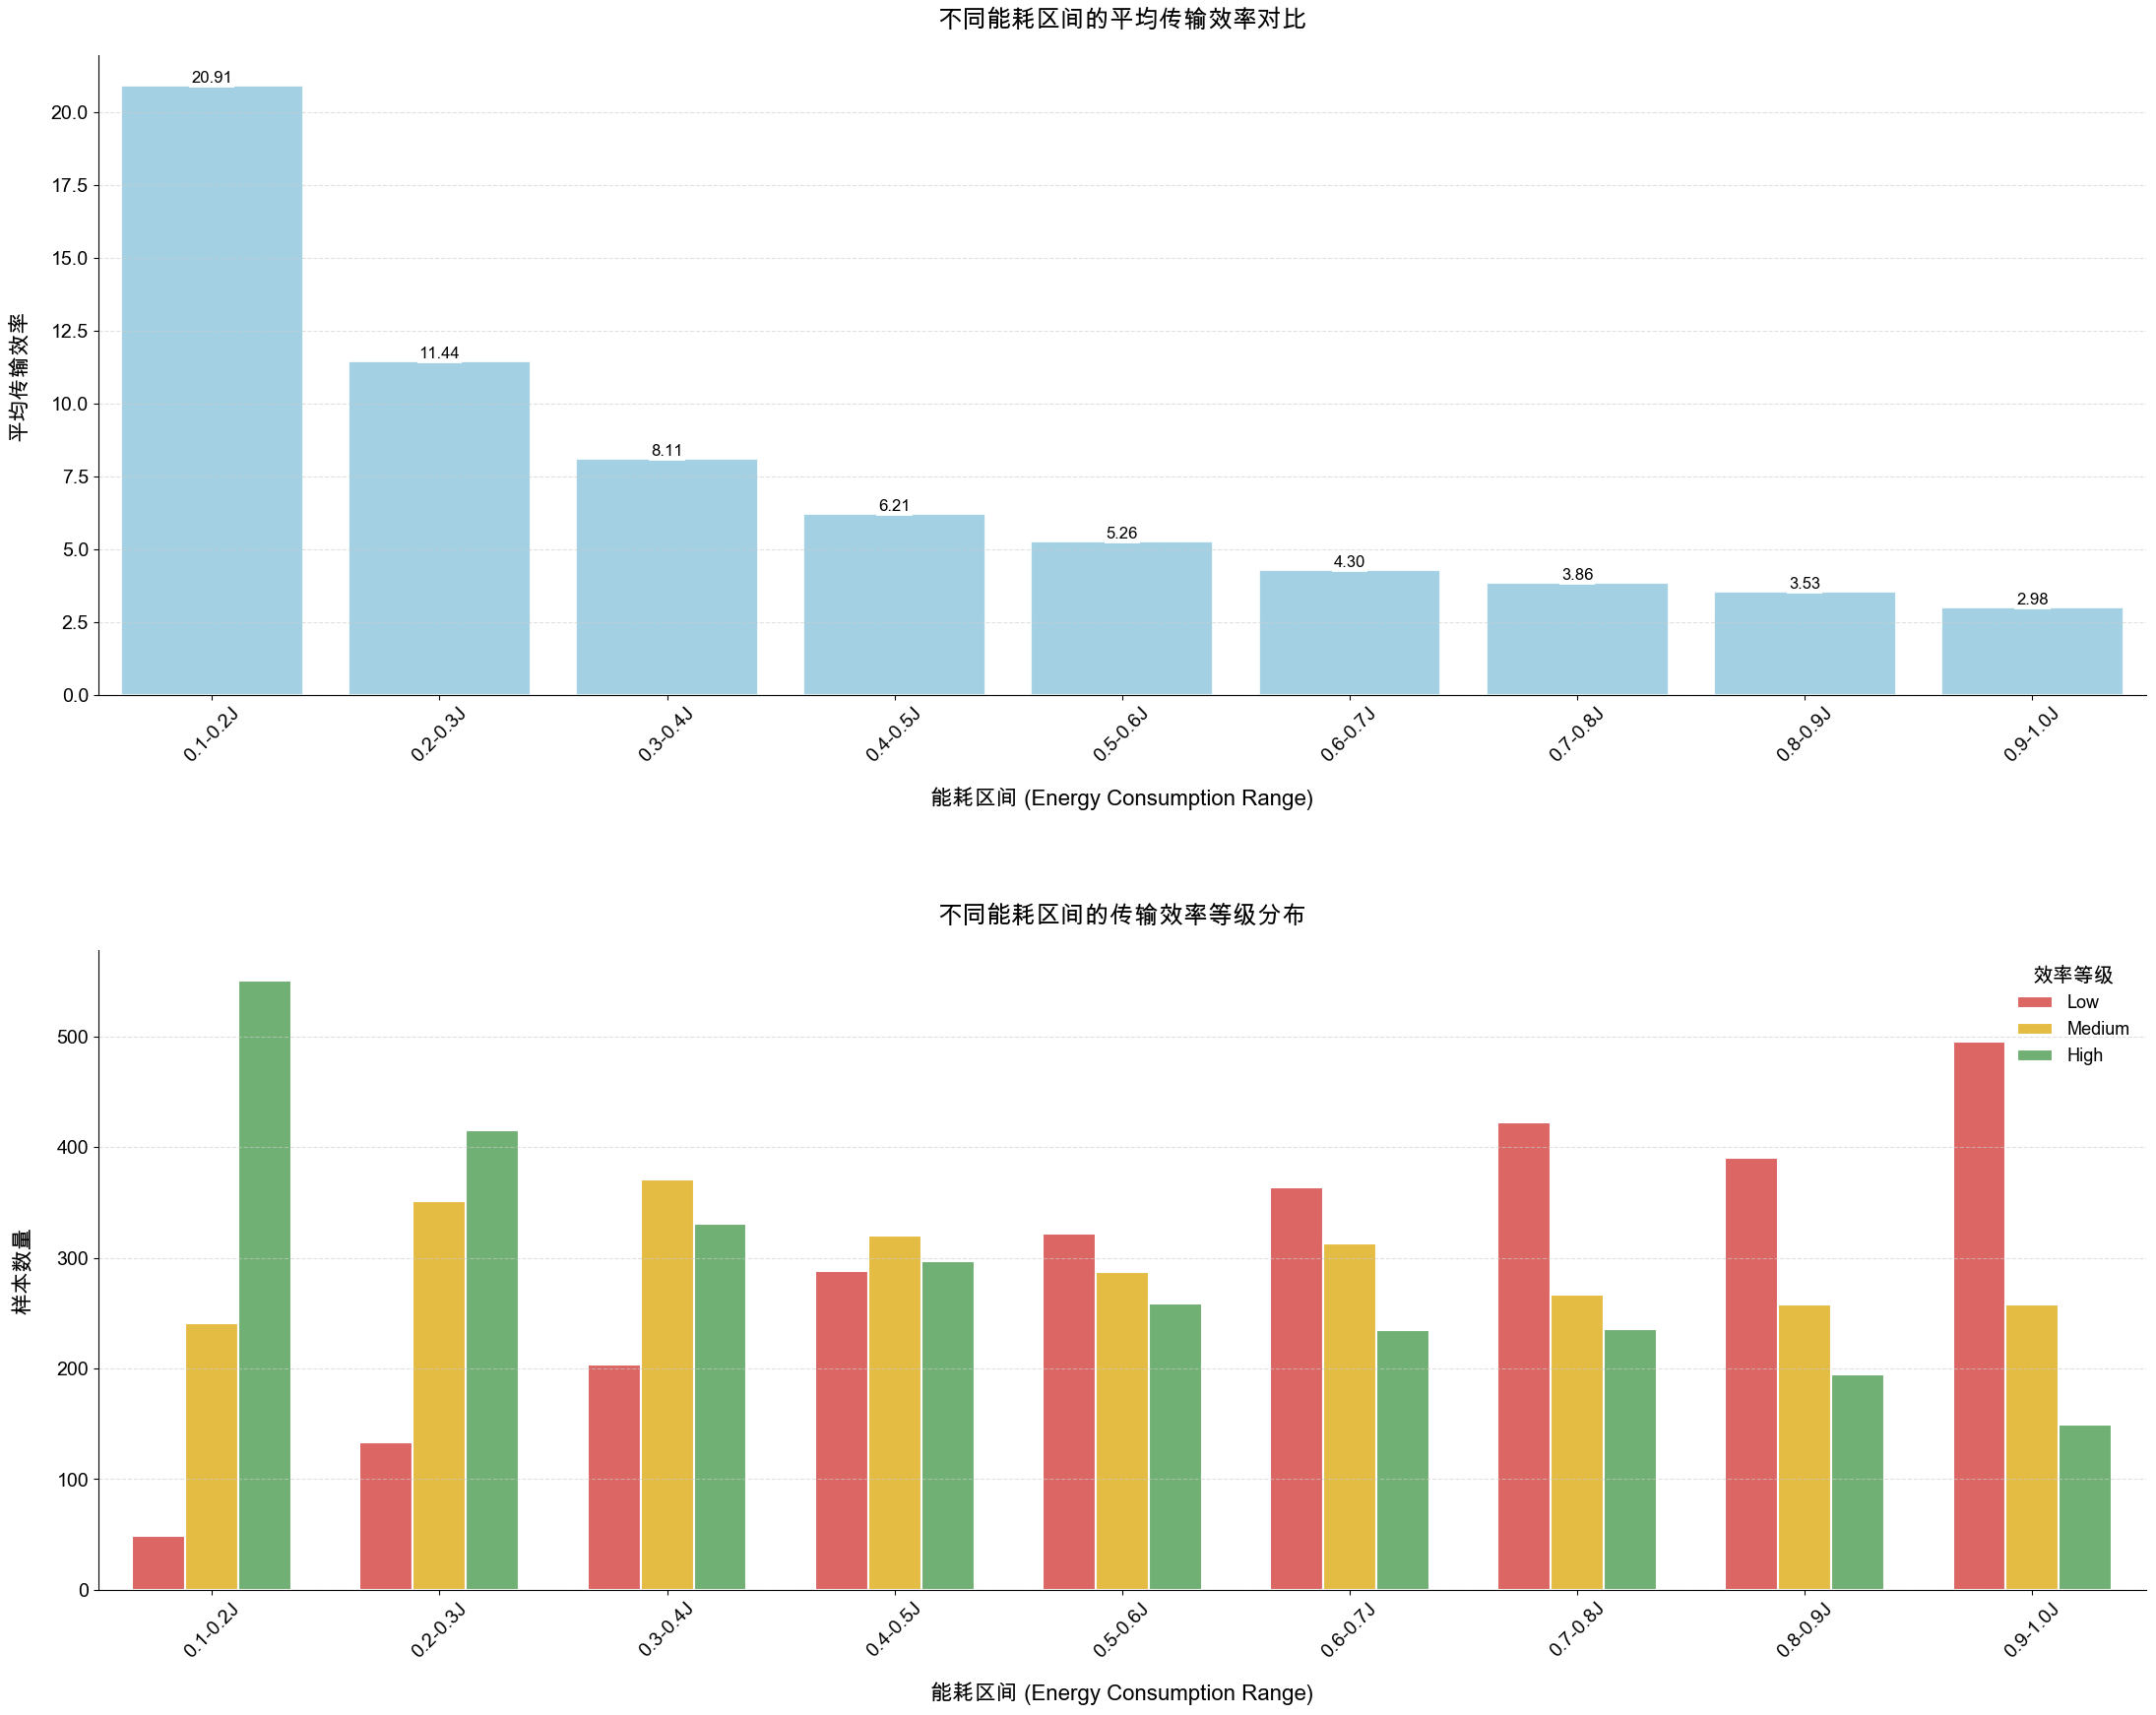

In [9]:
# --- 1. 数据预处理：构造能耗区间 (类似温度区间) ---
def get_energy_range(energy):
    """将连续的能耗划分为 0.1J 的区间标签"""
    # 计算区间的起始值 (例如 0.24 -> 0.2, 0.45 -> 0.4)
    start = round(int(energy * 10) / 10, 1)
    return f"{start:.1f}-{round(start+0.1, 1):.1f}J"

# 应用转换
train_data['EnergyRange'] = train_data['energy_consumption'].apply(get_energy_range)

# 确保传输效率等级列存在 (Low/Medium/High)
train_data['EfficiencyLevel'] = pd.qcut(train_data['transmission_efficiency'], q=3, labels=['Low', 'Medium', 'High'])

# 计算每个能耗区间的平均传输效率，并进行排序
# 按“能耗区间”本身排序，以便观察随能耗增加效率的变化趋势
# 先提取起始数值用于排序
temp_df = train_data.copy()
temp_df['range_start'] = temp_df['energy_consumption'].apply(lambda x: int(x * 10) / 10)
energy_efficiency_mean = temp_df.groupby(['EnergyRange', 'range_start'])['transmission_efficiency'].mean().reset_index()
energy_efficiency_mean = energy_efficiency_mean.sort_values('range_start')

# --- 2. 绘图 ---
f, ax = plt.subplots(2, 1, figsize=(22, 18))  # 保持大画布

# 子图1：各能耗区间平均传输效率（Bar Plot）
sns.barplot(
    data=energy_efficiency_mean,
    x='EnergyRange',
    y='transmission_efficiency',
    ax=ax[0],
    color='skyblue',
    edgecolor='white',
    linewidth=1.5,
    alpha=0.85
)

# 美化子图1
ax[0].set_title('不同能耗区间的平均传输效率对比', fontsize=18, pad=20, fontweight='bold')
ax[0].set_xlabel('能耗区间 (Energy Consumption Range)', fontsize=16, labelpad=15)
ax[0].set_ylabel('平均传输效率', fontsize=16, labelpad=15)
ax[0].grid(axis='y', linestyle='--', alpha=0.6, color='#cccccc')
ax[0].tick_params(axis='x', rotation=45, labelsize=14)
ax[0].tick_params(axis='y', labelsize=14)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

# 添加数值标签
for p in ax[0].patches:
    height = p.get_height()
    if height > 0:
        ax[0].annotate(
            f'{height:.2f}', 
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=12,
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.9)
        )

# 子图2：各能耗区间的传输效率等级分布（Count Plot）
order = energy_efficiency_mean['EnergyRange'].tolist()

sns.countplot(
    x='EnergyRange', 
    hue='EfficiencyLevel',  # 使用 Low/Medium/High
    data=train_data, 
    ax=ax[1],
    order=order, 
    width=0.7, 
    edgecolor='white', 
    linewidth=1.5,
    palette=['#EF5350', '#FFCA28', '#66BB6A'] # 红/黄/绿 分别代表低/中/高效率
)

# 美化子图2
ax[1].set_title('不同能耗区间的传输效率等级分布', fontsize=18, pad=20, fontweight='bold')
ax[1].set_xlabel('能耗区间 (Energy Consumption Range)', fontsize=16, labelpad=15)
ax[1].set_ylabel('样本数量', fontsize=16, labelpad=15)
ax[1].grid(axis='y', linestyle='--', alpha=0.6, color='#cccccc')
ax[1].tick_params(axis='x', rotation=45, labelsize=14)
ax[1].tick_params(axis='y', labelsize=14)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

# 图例优化
ax[1].legend(title='效率等级', title_fontsize=15, fontsize=13, loc='upper right', frameon=False)

# 整体布局
plt.tight_layout()
plt.subplots_adjust(hspace=0.4, bottom=0.1)
plt.show()

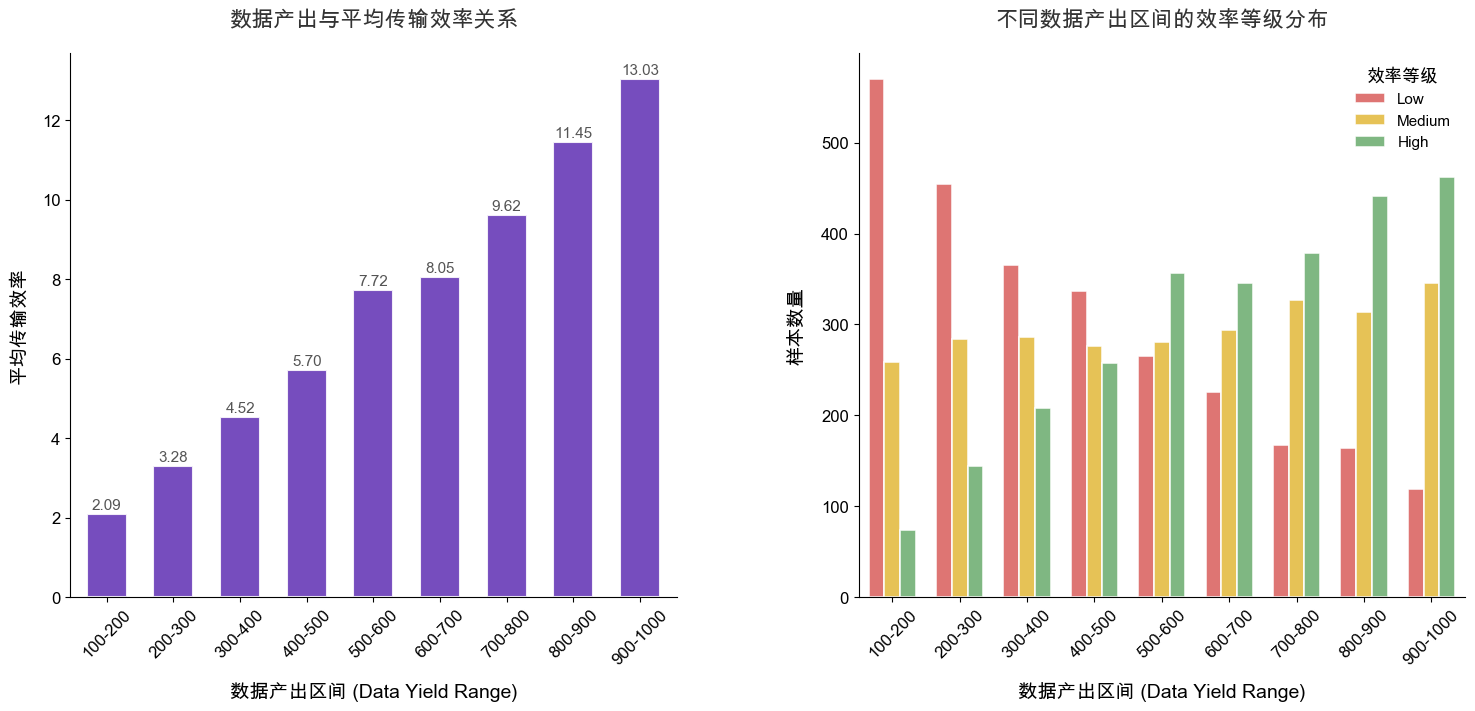

In [10]:
# --- 1. 数据预处理：构造数据产出区间 (类似碳含量区间) ---
# 定义 100 间隔的区间 (从 100 到 1000)
bins = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
labels = [f"{b}-{bins[i+1]}" for i, b in enumerate(bins[:-1])]

# 创建区间列
train_data['YieldRange'] = pd.cut(train_data['data_yield'], bins=bins, labels=labels, right=False)

# 确保效率等级列存在 (Low/Medium/High)
train_data['EfficiencyLevel'] = pd.qcut(train_data['transmission_efficiency'], q=3, labels=['Low', 'Medium', 'High'])

# 获取排序后的区间列表 (用于保持 X 轴顺序)
sorted_ranges = [label for label in labels if label in train_data['YieldRange'].unique()]

# 2. 计算平均传输效率 (对应左图数据)
yield_efficiency_mean = train_data[['YieldRange', 'transmission_efficiency']].groupby(['YieldRange']).mean()
yield_efficiency_mean = yield_efficiency_mean.reindex(sorted_ranges) # 按区间大小排序

# 3. 绘图
f, ax = plt.subplots(1, 2, figsize=(18, 8))
plt.subplots_adjust(wspace=0.3, bottom=0.2)  # 增加底部间距以容纳旋转后的标签

# 定义配色
mean_color = '#673AB7'  # 深紫色 (科技感)
# 右侧配色：红/黄/绿 对应 低/中/高 传输效率等级
count_colors = ['#EF5350', '#FFCA28', '#66BB6A'] 

# --- 左侧：数据产出与平均传输效率关系 ---
yield_efficiency_mean.plot.bar(
    y='transmission_efficiency',
    ax=ax[0],
    color=mean_color,
    width=0.6,
    edgecolor='white',
    linewidth=1.5,
    alpha=0.9,
    legend=False
)

# 标题与标签优化
ax[0].set_title('数据产出与平均传输效率关系', fontsize=16, pad=20, fontweight='bold', color='#333333')
ax[0].set_xlabel('数据产出区间 (Data Yield Range)', fontsize=14, labelpad=10)
ax[0].set_ylabel('平均传输效率', fontsize=14, labelpad=10)
ax[0].tick_params(axis='x', labelsize=12, rotation=45) 
ax[0].tick_params(axis='y', labelsize=12)

# 添加数值标签
for p in ax[0].patches:
    if pd.notna(p.get_height()):
        ax[0].text(
            p.get_x() + p.get_width()/2, p.get_height() + 0.05,
            f'{p.get_height():.2f}',
            ha='center', va='bottom', fontsize=11, color='#555555'
        )

# 去除边框
for spine in ax[0].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# --- 右侧：不同数据产出区间的效率等级分布 ---
sns.countplot(
    x='YieldRange',
    hue='EfficiencyLevel',
    data=train_data,
    ax=ax[1],
    palette=count_colors,
    width=0.7,
    edgecolor='white',
    linewidth=1.2,
    alpha=0.9,
    order=sorted_ranges 
)

# 标题与标签优化
ax[1].set_title('不同数据产出区间的效率等级分布', fontsize=16, pad=20, fontweight='bold', color='#333333')
ax[1].set_xlabel('数据产出区间 (Data Yield Range)', fontsize=14, labelpad=10)
ax[1].set_ylabel('样本数量', fontsize=14, labelpad=10)
ax[1].tick_params(axis='x', labelsize=12, rotation=45)
ax[1].tick_params(axis='y', labelsize=12)

# 优化图例
ax[1].legend(
    title='效率等级',
    title_fontsize=13,
    fontsize=11,
    loc='upper right',
    frameon=False
)

# 去除边框
for spine in ax[1].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

plt.show()

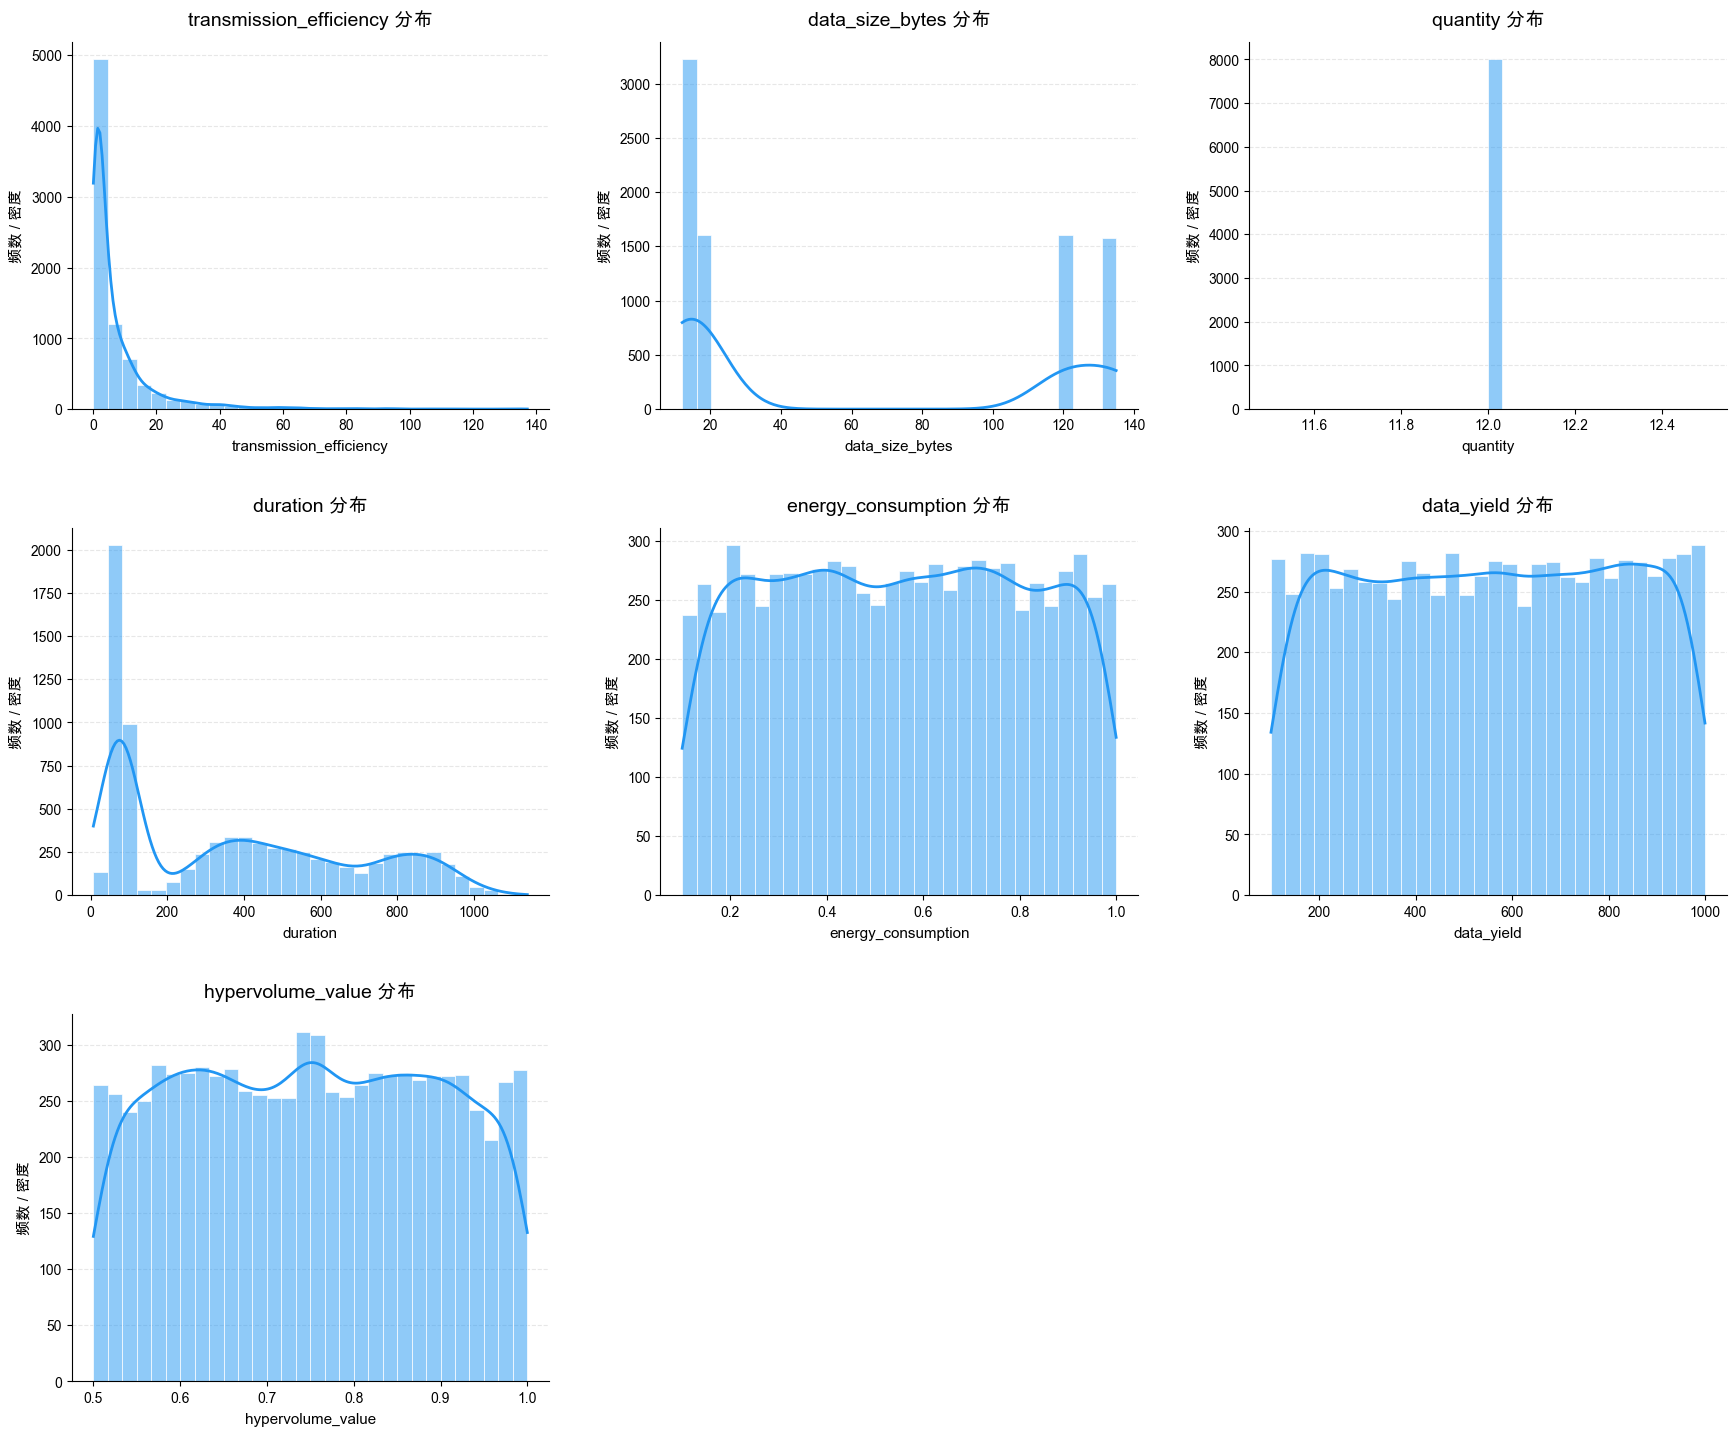

In [11]:
# 1. 预处理：确保数值列格式正确
# 新数据集特征较为规整，但为了健壮性，我们将所有数值列强制转换
numeric_cols = [
    'transmission_efficiency', # 传输效率 (Target)
    'data_size_bytes',          # 数据大小
    'quantity',                 # 数量
    'duration',                 # 时长
    'energy_consumption',       # 能耗
    'data_yield',               # 数据产出
    'hypervolume_value'         # 超体积值
]

for col in numeric_cols:
    train_data[col] = pd.to_numeric(train_data[col], errors='coerce')

# 过滤掉目标变量缺失的行
plot_data = train_data.dropna(subset=['transmission_efficiency'])

# 2. 定义 IoT 数据集的数值型特征
NUM_FEATURE_NAMES = numeric_cols

# 设置绘图风格
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# 计算子图布局（3行3列 = 9个槽位，实际使用7个）
n_rows = 3
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 15))
axes = axes.flatten()

# 定义科技感配色
hist_color = '#2196F3'  # 科技蓝
kde_color = '#FF5722'   # 橙红色曲线

for i, feature in enumerate(NUM_FEATURE_NAMES):
    ax = axes[i]
    
    if feature in plot_data.columns:
        # 去除 NaN 值进行绘图
        feature_data = plot_data[feature].dropna()
        
        sns.histplot(
            data=feature_data, 
            bins=30, 
            kde=True,
            ax=ax,
            color=hist_color,
            edgecolor='white',
            linewidth=0.5,
            line_kws={
                'color': kde_color,
                'linewidth': 2
            }
        )
        
        # 设置标题和标签（中文注释）
        ax.set_title(f'{feature} 分布', pad=12, fontweight='bold')
        ax.set_xlabel(feature, labelpad=5)
        ax.set_ylabel('频数 / 密度', labelpad=5)
        
        # 美化：去除顶部和右侧边框
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # 添加轻微的水平网格线
        ax.yaxis.grid(True, linestyle='--', alpha=0.3)
        ax.set_axisbelow(True)
    else:
        ax.set_visible(False)

# 隐藏多余的空白子图（最后两个槽位）
for j in range(len(NUM_FEATURE_NAMES), len(axes)):
    axes[j].set_visible(False)

# 调整布局，增加标题间的间距
plt.tight_layout(pad=3.0)
plt.show()

# <a id='toc5_'></a>[工具函数](#toc0_)

In [12]:
# ------------------------------------------------------------------
# 定义回归任务的工具函数
# ------------------------------------------------------------------
def rmse(y_true, y_pred):
    """计算均方根误差 (RMSE)"""
    return np.sqrt(mean_squared_error(y_true, y_pred))

# <a id='toc6_'></a>[数据预处理](#toc0_)

功能：处理数据中的缺失值和异常值，同时记录异常/缺失标记，为建模做准备

In [13]:
from sklearn.preprocessing import LabelEncoder

class DataPreprocessing:
    def __init__(self):
        self.medians = None
        self.modes = None
        # 更新 IoT 场景下的数值约束
        self.constraints = {
            'data_size_bytes': (0, None),
            'quantity': (0, None),
            'duration': (0, None),
            'energy_consumption': (0, 1), # 假设能耗在 0-1 焦耳之间
            'data_yield': (0, None),
            'hypervolume_value': (0, 1),
            # 'transmission_efficiency': (0, None) # 预测目标
        }
        # 用于存储分类特征编码器
        self.encoders = {}

    def fit(self, X):
        X = X.copy()
        
        # 1. 确保所有可能的数值列都已转换，以便计算中位数
        numeric_cols = list(self.constraints.keys())
        for col in numeric_cols:
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors='coerce')
        
        # 学习数值型特征的中位数和众数
        self.medians = X.median(numeric_only=True)
        self.modes = X.mode().iloc[0] if not X.empty else None

        # 2. 学习分类特征的编码映射 (针对新字段 sensor_type)
        categorical_cols = ['sensor_type']
        for col in categorical_cols:
            if col in X.columns:
                le = LabelEncoder()
                # 处理 NaN 并转为字符串
                data_to_fit = X[col].fillna('Missing').astype(str)
                le.fit(data_to_fit)
                self.encoders[col] = le
        
    def transform(self, X):
        X = X.copy()
        
        # 1. 数值类型强制转换
        numeric_cols = list(self.constraints.keys())
        for col in numeric_cols:
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors='coerce')
        
        # 2. 约束处理、缺失值标记与物理边界裁剪
        for col, (min_val, max_val) in self.constraints.items():
            if col in X.columns:
                # 记录原始 NaN 位置（新增特征工程）
                # X[f'{col}_is_NaN'] = X[col].isna().astype(int)
                
                # 物理边界裁剪
                if min_val is not None: X[col] = X[col].clip(lower=min_val)
                if max_val is not None: X[col] = X[col].clip(upper=max_val)

        # 3. 数值型缺失值填充（使用 fit 阶段学习到的中位数）
        X = X.fillna(self.medians)
        
        # 4. 分类特征编码处理 (Label Encoding)
        for col, le in self.encoders.items():
            if col in X.columns:
                # 处理未见过的类别：
                # 将输入数据中不在 le.classes_ 中的值替换为众数或 'Missing'
                valid_classes = set(le.classes_)
                X[col] = X[col].fillna('Missing').astype(str).apply(
                    lambda x: x if x in valid_classes else 'Missing'
                )
                
                # 如果 'Missing' 在 fit 时不存在，le 依然会报错
                # 这里做一层安全兜底，将未知项强制映射为 classes_ 的第一个索引
                try:
                    X[col] = le.transform(X[col])
                except ValueError:
                    # 极端情况下（如测试集全是新类别且没 fit 'Missing'）的处理
                    X[col] = 0
                
        # 5. 最终兜底填充，确保输出无 NaN
        X = X.fillna(0)
        
        # 建议：删除 query_id 等无意义的 ID 列（如果在 X 中）
        if 'query_id' in X.columns:
            X = X.drop(columns=['query_id'])
            
        return X

# <a id='toc7_'></a>[特征工程](#toc0_)

In [14]:
class FeatureGenerator:
    """
    特征生成器类 - 专为 IoT 传感器数据传输任务设计
    用于生成具有通信和计算物理意义的衍生特征，如吞吐量、能耗效率、任务强度等。
    """
    
    def transform(self, X):
        """
        对输入数据进行特征转换处理
        
        参数:
            X: pandas.DataFrame，原始输入数据 (需包含 data_size_bytes, duration, energy_consumption 等列)
            
        返回:
            pandas.DataFrame，处理后的特征数据 (包含 15+ 衍生特征)
        """
        # 复制输入数据，避免修改原始数据
        X = X.copy()
        
        print("开始 IoT 传输特征工程...")
        
        # 为了计算安全，定义一个极小量防止除以零
        eps = 1e-9
        
        # ------------------------------------------------------------------
        # 1. 任务负载特征 (Task Load Features)
        # ------------------------------------------------------------------
        # 总传输字节数 (Total Bytes)
        X['total_data_volume'] = X['data_size_bytes'] * X['quantity']
        
        # 任务密度 (Task Density) - 单位字节所承载的观测数量
        X['quantity_per_byte'] = X['quantity'] / (X['data_size_bytes'] + eps)
        
        # ------------------------------------------------------------------
        # 2. 吞吐量与时效性 (Throughput & Temporal Features)
        # ------------------------------------------------------------------
        # 网络吞吐量 (Throughput) - 每单位时间传输的数据量
        X['throughput'] = X['total_data_volume'] / (X['duration'] + eps)
        
        # 处理速率 (Processing Rate) - 每单位时间处理的传感器观测数量
        X['processing_rate'] = X['quantity'] / (X['duration'] + eps)
        
        # 逆时长 (Efficiency of Time)
        X['inv_duration'] = 1.0 / (X['duration'] + eps)
        
        # 时长平方 (Penalty for Latency) - 用于捕捉长延迟任务的性能衰减
        X['duration_squared'] = X['duration'] ** 2
        
        # ------------------------------------------------------------------
        # 3. 能效特征 (Energy Efficiency Features)
        # ------------------------------------------------------------------
        # 单位字节能耗 (Energy per Byte)
        X['energy_per_byte'] = X['energy_consumption'] / (X['total_data_volume'] + eps)
        
        # 任务平均功率 (Average Power) - 传输过程中的能量消耗速率
        X['avg_power'] = X['energy_consumption'] / (X['duration'] + eps)
        
        # 能量收益比 (Yield per Energy)
        X['yield_per_energy'] = X['data_yield'] / (X['energy_consumption'] + eps)
        
        # 能耗非线性项 (Energy Intensity)
        X['energy_log'] = np.log1p(X['energy_consumption'])
        
        # ------------------------------------------------------------------
        # 4. 产出与优化指标 (Yield & Optimization Features)
        # ------------------------------------------------------------------
        # 时间产出效率 (Yield per Time)
        X['yield_per_time'] = X['data_yield'] / (X['duration'] + eps)
        
        # 综合收益指数 (Combined Productivity Index)
        X['productivity_index'] = (X['data_yield'] * X['quantity']) / (X['duration'] + eps)
        
        # 资源平衡因子 (Resource Balance Factor) - 产出与能耗+时长的比例
        X['resource_balance'] = X['data_yield'] / (X['energy_consumption'] + X['duration'] * 0.001 + eps)
        
        # 超体积负载比 (HV per Load) - 衡量优化程度与任务大小的关系
        X['hv_load_ratio'] = X['hypervolume_value'] / (X['data_size_bytes'] + eps)
        
        # ------------------------------------------------------------------
        # 5. 交互与对数变换 (Interaction & Non-linear Features)
        # ------------------------------------------------------------------
        # 能耗与超体积的权衡交互 (Energy-HV Trade-off)
        X['energy_hv_interaction'] = X['energy_consumption'] * X['hypervolume_value']
        
        # 任务强度对数 (Log Task Intensity)
        X['log_total_volume'] = np.log1p(X['total_data_volume'])
        
        # 产出与数据大小的交互 (Yield-Size Synergy)
        X['yield_size_interaction'] = X['data_yield'] * X['data_size_bytes']
        
        # ------------------------------------------------------------------
        # 6. 传感器特异性特征 (Sensor Specific Potential - 示例)
        # ------------------------------------------------------------------
        # 如果传感器类型对传输效率有基准影响
        # 这里仅展示数值交互，分类特征通常在 DataPreprocessing 中处理
        X['hv_energy_ratio'] = X['hypervolume_value'] / (X['energy_consumption'] + eps)

        return X

1. 从训练数据中分离目标变量和特征数据，复制测试数据。
2. 用训练特征拟合预处理模型，再分别对训练和测试特征做预处理。
3. 通过特征生成器对预处理后的训练、测试特征进行特征工程，确保处理一致性，为建模做准备。

In [15]:
print(train.shape)
print(test.shape)

(8000, 9)
(2000, 9)


In [16]:
# 定义目标变量列名
target_col = "transmission_efficiency"

# 复制测试数据（避免后续操作修改原始测试数据）
test_X  = test.copy()
test_X = test_X.drop(target_col, axis=1)
test_y = test[target_col]

# 从训练数据中提取目标变量
train_X = train.drop(target_col, axis=1)
y = train[target_col]

# 初始化数据预处理类实例（假设该类包含缺失值处理、异常值处理等基础预处理逻辑）
preprocessor = DataPreprocessing()

# 用训练数据拟合预处理模型（学习训练数据中的统计特性，如缺失值填充策略等）
preprocessor.fit(train_X)

# 对训练特征数据应用预处理（使用拟合好的参数对训练数据进行转换）
train_proc = preprocessor.transform(train_X)

# 对测试特征数据应用同样的预处理（保证训练集和测试集处理方式一致）
test_proc  = preprocessor.transform(test_X)

# 初始化特征生成器实例（即前面定义的FeatureGenerator类，用于生成高级特征）
feat_gen = FeatureGenerator()

# 对预处理后的训练数据进行特征工程（生成衍生特征，如比例特征、交互特征等）
train_fe = feat_gen.transform(train_proc)

# 对预处理后的测试数据进行同样的特征工程（保持特征一致性）
test_fe  = feat_gen.transform(test_proc)

print(train_fe.shape)
print(test_fe.shape)

开始 IoT 传输特征工程...
开始 IoT 传输特征工程...
(8000, 25)
(2000, 25)


# <a id='toc8_'></a>[贝叶斯优化参数空间](#toc0_)

In [17]:
def bayes_opt(model, space, X, y, cv=2, n_iter=1, scoring='neg_root_mean_squared_error', rnd=42):
    """通用贝叶斯优化 (修改为回归评分)"""
    opt = BayesSearchCV(
        model, space, n_iter=n_iter, cv=cv, scoring=scoring,
        random_state=rnd, n_jobs=-1, verbose=0
    )
    opt.fit(X, y)
    return opt.best_estimator_, opt.best_params_

# ------------------------------------------------------------------
# 贝叶斯优化参数空间
# ------------------------------------------------------------------
lgb_space = {
    'n_estimators': Integer(200, 1500),          # <--- 修改: 缩小范围
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
    'num_leaves': Integer(20, 60),              # <--- 修改: 缩小范围
    'max_depth': Integer(3, 8),                 # <--- 修改: 缩小范围
    'min_child_samples': Integer(20, 80),       # <--- 修改: 缩小范围
    'reg_alpha': Real(0.1, 1.0),
    'reg_lambda': Real(0.1, 1.0),
}

xgb_space = {
    'n_estimators': Integer(200, 1500),          # <--- 修改: 缩小范围
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
    'max_depth': Integer(3, 8),                 # <--- 修改: 缩小范围
    'min_child_weight': Integer(1, 10),
    'gamma': Real(0, 0.5),
    'subsample': Real(0.7, 1.0),
    'colsample_bytree': Real(0.7, 1.0),
    'reg_alpha': Real(0.1, 1.0),
    'reg_lambda': Real(0.1, 1.0),
}

cat_space = {
    'iterations': Integer(200, 1500),            # <--- 修改: 缩小范围
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
    'depth': Integer(3, 8),                     # <--- 修改: 缩小范围
    'l2_leaf_reg': Real(0.1, 10.0),
}

# ------------------------------------------------------------------
# 小样本快速优化
# ------------------------------------------------------------------
sample_idx, _ = train_test_split(
    np.arange(len(train_fe)), train_size=100, random_state=42)
X_sample, y_sample = train_fe.iloc[sample_idx], y.iloc[sample_idx]

# 迭代次数
N_ITER_FAST = 12

print('【LightGBM 贝叶斯优化】')
_, lgb_best = bayes_opt(
    lgb.LGBMRegressor(objective='regression', metric='rmse', random_state=42, n_jobs=-1, verbose=-1),
    lgb_space, X_sample, y_sample, n_iter=N_ITER_FAST) # <--- 使用新的迭代次数

print('【XGBoost 贝叶斯优化】')
_, xgb_best = bayes_opt(
    xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse',
                      tree_method='hist', random_state=42, n_jobs=-1),
    xgb_space, X_sample, y_sample, n_iter=N_ITER_FAST) # <--- 使用新的迭代次数

print('【CatBoost 贝叶斯优化】')
_, cat_best = bayes_opt(
    cb.CatBoostRegressor(loss_function='RMSE', eval_metric='RMSE',
                         thread_count=-1, random_state=42, verbose=False), # 加上此参数防止文件报错
    cat_space, X_sample, y_sample, n_iter=N_ITER_FAST) # <--- 使用新的迭代次数

【LightGBM 贝叶斯优化】
【XGBoost 贝叶斯优化】
【CatBoost 贝叶斯优化】


# <a id='toc10_'></a>[5 折交叉验证训练](#toc0_)

In [18]:
# ------------------------------------------------------------------
# 5 折 KFold 交叉验证训练
# ------------------------------------------------------------------

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_lgb, oof_xgb, oof_cat = np.zeros(len(train_fe)), np.zeros(len(train_fe)), np.zeros(len(train_fe))
pred_lgb, pred_xgb, pred_cat = np.zeros(len(test_fe)), np.zeros(len(test_fe)), np.zeros(len(test_fe))

for fold, (tr, va) in enumerate(kf.split(train_fe, y), 1):
    print(f'=== Fold {fold} ===')
    X_tr, X_va = train_fe.iloc[tr], train_fe.iloc[va]
    y_tr, y_va = y.iloc[tr], y.iloc[va]

    # LightGBM
    print("LightGBM")
    m_lgb = lgb.LGBMRegressor(**lgb_best, objective='regression', metric='rmse', n_jobs=-1, verbose=-1)
    m_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(100, verbose=False)])
    oof_lgb[va] = m_lgb.predict(X_va)
    pred_lgb += m_lgb.predict(test_fe) / kf.n_splits

    # XGBoost
    print("XGBoost")
    m_xgb = xgb.XGBRegressor(**xgb_best, objective='reg:squarederror', tree_method='hist', n_jobs=-1)
    m_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=0)
    oof_xgb[va] = m_xgb.predict(X_va)
    pred_xgb += m_xgb.predict(test_fe) / kf.n_splits

    # CatBoost
    print("CatBoost")
    m_cat = cb.CatBoostRegressor(**cat_best, thread_count=-1, verbose=False)
    m_cat.fit(X_tr, y_tr, eval_set=(X_va, y_va), use_best_model=True)
    oof_cat[va] = m_cat.predict(X_va)
    pred_cat += m_cat.predict(test_fe) / kf.n_splits

    rmse_lgb_fold = rmse(y_va, oof_lgb[va])
    rmse_xgb_fold = rmse(y_va, oof_xgb[va])
    rmse_cat_fold = rmse(y_va, oof_cat[va])
    print(f'Fold RMSE -> LGB:{rmse_lgb_fold:.4f} XGB:{rmse_xgb_fold:.4f} CAT:{rmse_cat_fold:.4f}')

=== Fold 1 ===
LightGBM
XGBoost
CatBoost
Fold RMSE -> LGB:3.5331 XGB:1.4855 CAT:1.1054
=== Fold 2 ===
LightGBM
XGBoost
CatBoost
Fold RMSE -> LGB:3.5317 XGB:1.0723 CAT:1.0486
=== Fold 3 ===
LightGBM
XGBoost
CatBoost
Fold RMSE -> LGB:4.2379 XGB:1.9083 CAT:1.6198
=== Fold 4 ===
LightGBM
XGBoost
CatBoost
Fold RMSE -> LGB:3.0318 XGB:0.9565 CAT:0.8619
=== Fold 5 ===
LightGBM
XGBoost
CatBoost
Fold RMSE -> LGB:3.3336 XGB:0.8808 CAT:0.9459


# <a id='toc11_'></a>[模型融合](#toc0_)

## <a id='toc11_1_'></a>[加权融合（权重按 OOF F1 的幂次）](#toc0_)

In [19]:
# ------------------------------------------------------------------
# 加权融合 与 Stacking
# ------------------------------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# 加权融合
rmse_lgb = rmse(y, oof_lgb)
rmse_xgb = rmse(y, oof_xgb)
rmse_cat = rmse(y, oof_cat)
inv_rmses = 1 / np.array([rmse_lgb, rmse_xgb, rmse_cat])
weights = inv_rmses / inv_rmses.sum()

oof_blend = weights[0]*oof_lgb + weights[1]*oof_xgb + weights[2]*oof_cat
pred_blend = weights[0]*pred_lgb + weights[1]*pred_xgb + weights[2]*pred_cat
blend_rmse = rmse(y, oof_blend)
print(f'\n>>> 加权融合 OOF RMSE = {blend_rmse:.4f}')

# Stacking
stack_X = np.vstack([oof_lgb, oof_xgb, oof_cat]).T
stack_test = np.vstack([pred_lgb, pred_xgb, pred_cat]).T
stack_models = {
    'LR': LinearRegression(),
    'RF': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}
stack_res = {}
for name, mdl in stack_models.items():
    mdl.fit(stack_X, y)
    train_rmse = rmse(y, mdl.predict(stack_X))
    # 存储模型实例和它的RMSE分数
    stack_res[name] = {'model': mdl, 'rmse': train_rmse}
    print(f'  {name} Stacking RMSE = {train_rmse:.4f}')

# API修改：从max(f1)改为min(rmse)来选择最优模型
best_stack_name = min(stack_res, key=lambda x: stack_res[x]['rmse'])
best_stack_model = stack_res[best_stack_name]['model']

# 使用最优的stacking模型生成最终预测
best_stack_pred = best_stack_model.predict(stack_test)
print(f'>>> 选择 Stacking 模型：{best_stack_name}')


>>> 加权融合 OOF RMSE = 1.3577
  LR Stacking RMSE = 1.0400
  RF Stacking RMSE = 0.3817
>>> 选择 Stacking 模型：RF


# <a id='toc12_'></a>[提交文件](#toc0_)

In [20]:
# ------------------------------------------------------------------
# 提交文件
# ------------------------------------------------------------------
sub = pd.DataFrame(columns=['query_id', 'transmission_efficiency'])
sub['query_id'] = test['query_id']
sub['transmission_efficiency'] = best_stack_pred
sub.to_csv(SUBMISSION_OUT, index=False)
print(f'>>> 提交文件已保存：{SUBMISSION_OUT}')

>>> 提交文件已保存：submission.csv


# <a id='toc13_'></a>[结果可视化](#toc0_)

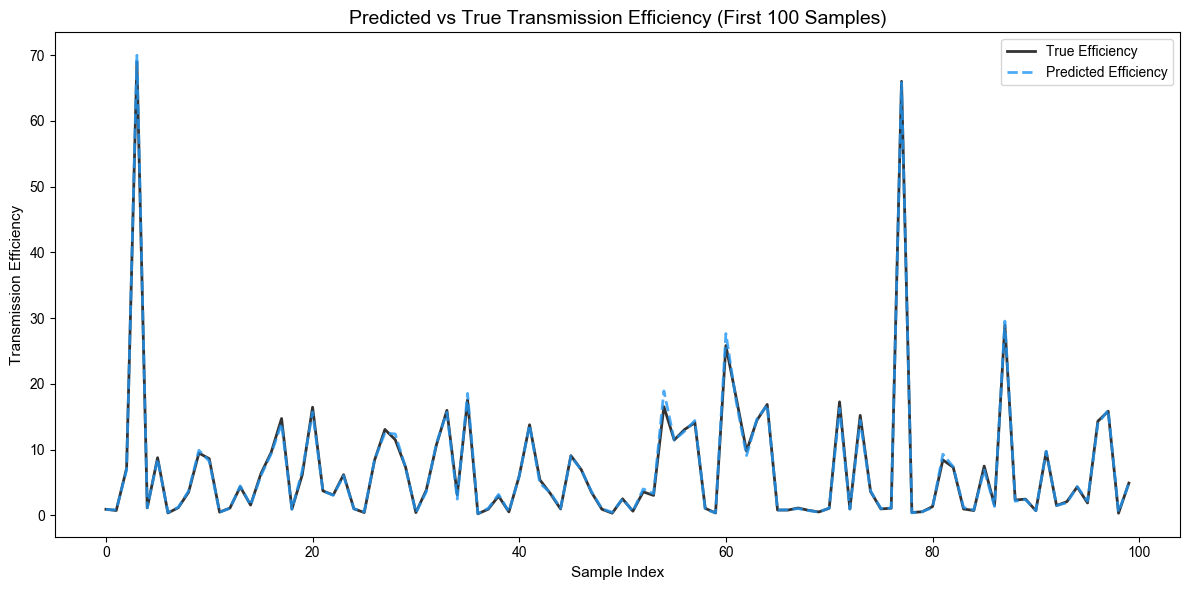

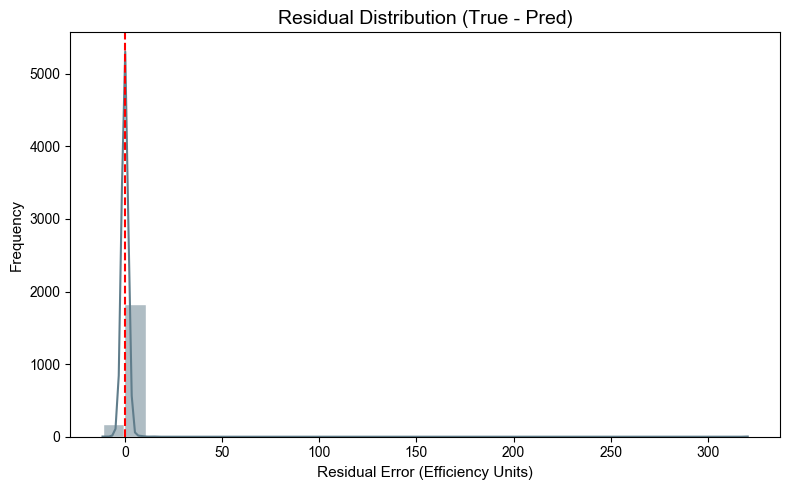

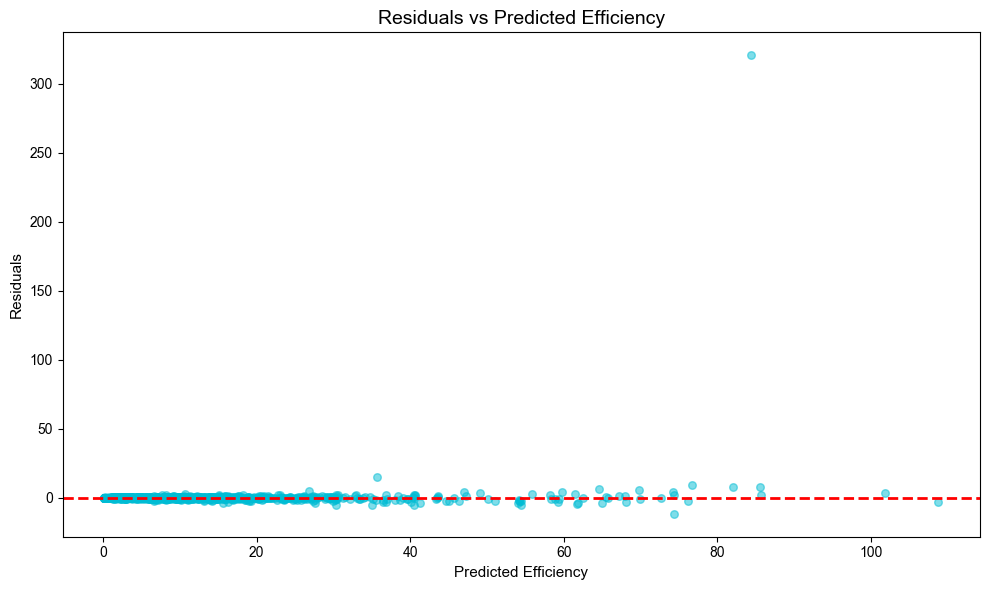

>>> 绘制 LightGBM 特征重要性


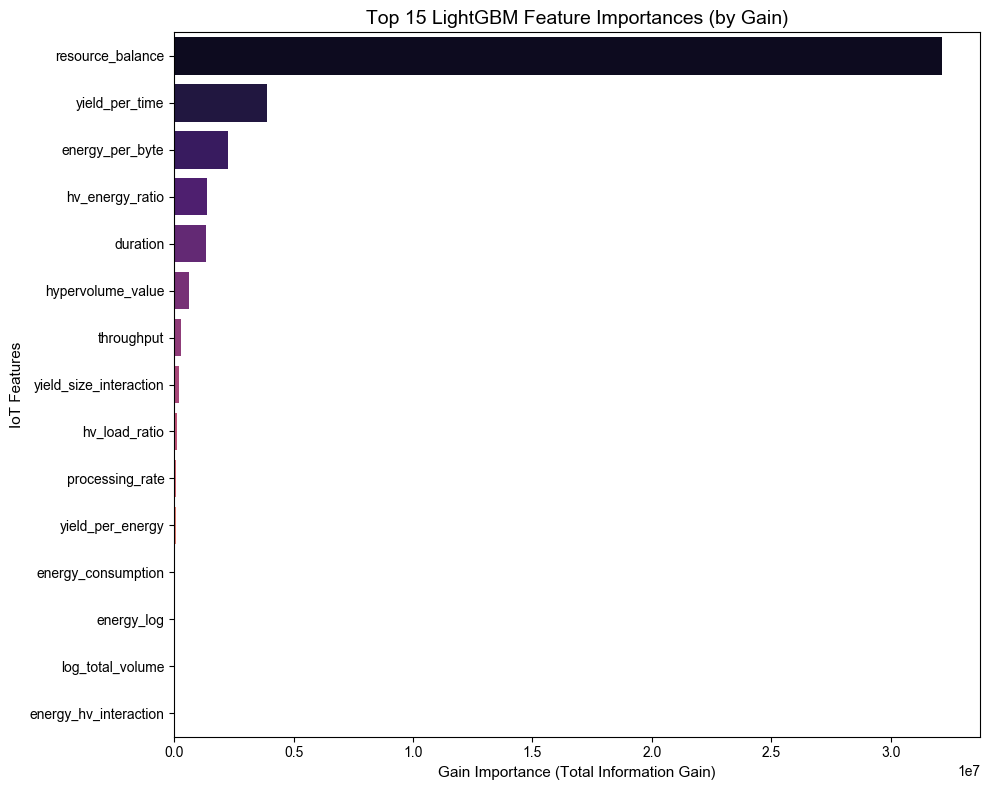

>>> SHAP 可解释性分析 (以 LightGBM 为例)


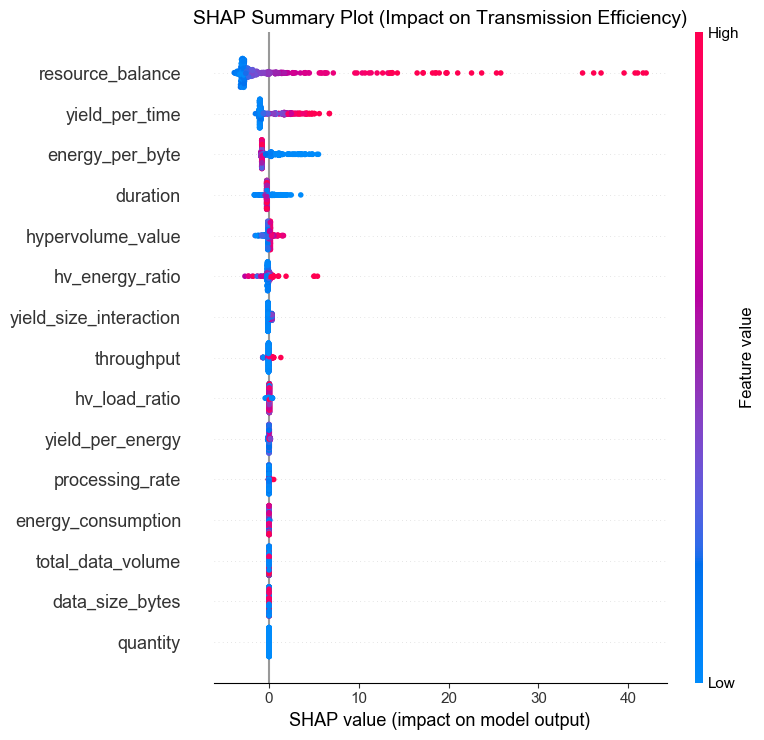

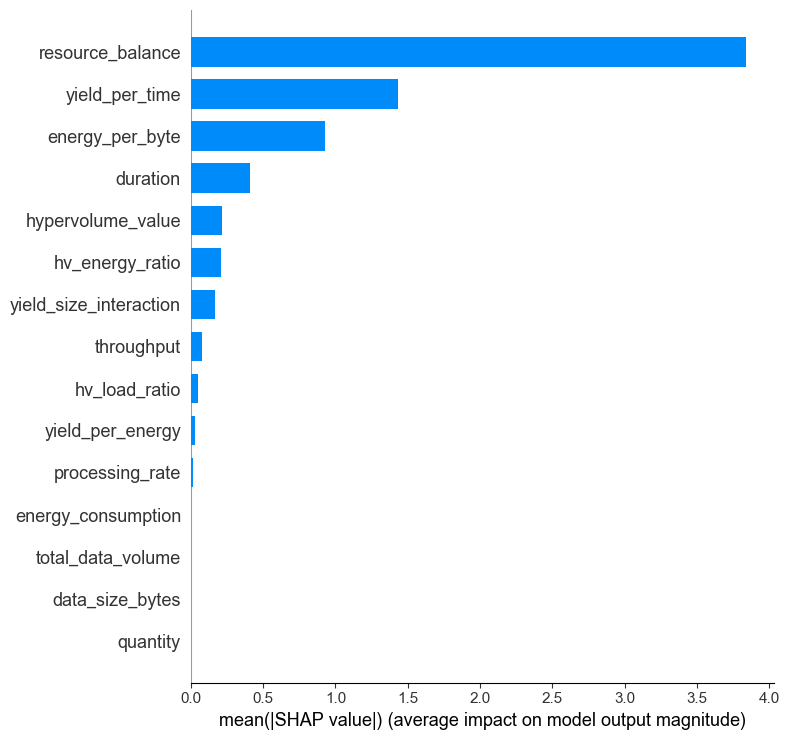

绘制最重要特征 [resource_balance] 的依赖图...


<Figure size 640x480 with 0 Axes>

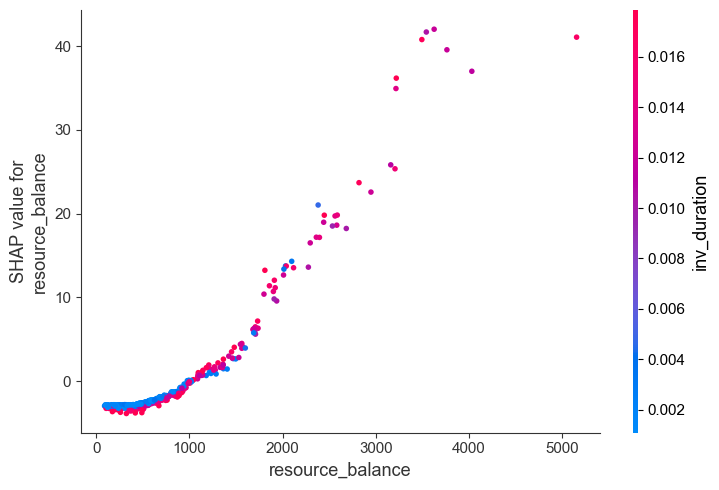

In [21]:
# 确保文件夹存在
os.makedirs('figs', exist_ok=True)
save = lambda name: plt.savefig(f'figs/{name}.png', dpi=300, bbox_inches='tight')

# ==========================================
# 1. 预测结果对比 (Prediction vs True)
# ==========================================
# 为了图表清晰，只画前 100 个样本
n_view = 100 
subset_idx = range(min(n_view, len(test_y)))

plt.figure(figsize=(12, 6))
plt.plot(test_y.values[subset_idx], label='True Efficiency', linewidth=2, color='#333333', linestyle='-')
plt.plot(best_stack_pred[subset_idx], label='Predicted Efficiency', linewidth=2, color='#2196F3', linestyle='--', alpha=0.8)

plt.title(f'Predicted vs True Transmission Efficiency (First {len(subset_idx)} Samples)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Transmission Efficiency')
plt.legend()
plt.tight_layout()
save('efficiency_prediction_vs_true')
plt.show()
plt.close()

# ==========================================
# 2. 残差分布 (Residual Distribution)
# ==========================================
residuals = test_y - best_stack_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=30, color='#607D8B', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5) # 添加0线参考

plt.title('Residual Distribution (True - Pred)', fontsize=14)
plt.xlabel('Residual Error (Efficiency Units)')
plt.ylabel('Frequency')
plt.tight_layout()
save('efficiency_residual_distribution')
plt.show()
plt.close()

# ==========================================
# 3. 残差诊断：残差 vs 预测值 (Residuals vs Predicted)
# ==========================================
plt.figure(figsize=(10, 6))
plt.scatter(best_stack_pred, residuals, alpha=0.5, color='#00BCD4', s=30)
plt.axhline(0, color='red', linestyle='--', linewidth=2)

plt.title('Residuals vs Predicted Efficiency', fontsize=14)
plt.xlabel('Predicted Efficiency')
plt.ylabel('Residuals')
plt.tight_layout()
save('efficiency_residual_vs_predicted')
plt.show()
plt.close()

# ==========================================
# 4. 特征重要性 (LightGBM Feature Importance)
# ==========================================
print(">>> 绘制 LightGBM 特征重要性")
# 假设 m_lgb 是针对新数据训练好的 LightGBM 模型
if 'm_lgb' in locals():
    lgb_booster = m_lgb.booster_ if hasattr(m_lgb, 'booster_') else m_lgb
    importance = lgb_booster.feature_importance(importance_type='gain')
    feat_names = test_fe.columns # 使用包含衍生特征的测试集列名
    
    # 构建 DataFrame 并排序
    imp_df = pd.DataFrame({
        'Feature': feat_names,
        'Gain': importance
    }).sort_values(by='Gain', ascending=False).head(15) # 取前 15 个重要特征
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Gain', y='Feature', data=imp_df, palette='magma', hue='Feature', legend=False)
    plt.title('Top 15 LightGBM Feature Importances (by Gain)', fontsize=14)
    plt.xlabel('Gain Importance (Total Information Gain)')
    plt.ylabel('IoT Features')
    plt.tight_layout()
    save('iot_lgb_feature_importance')
    plt.show()
    plt.close()
else:
    print("m_lgb 模型未定义，跳过特征重要性绘图。")

# ==========================================
# 5. SHAP 模型解释
# ==========================================
print(">>> SHAP 可解释性分析 (以 LightGBM 为例)")

if 'm_lgb' in locals():
    # 1. 准备解释器
    explainer = shap.TreeExplainer(m_lgb)
    
    # 2. 计算 SHAP 值 (抽取 500 个样本以平衡速度与准确性)
    sample_num = min(500, test_fe.shape[0])
    sample_idxs = np.random.choice(test_fe.shape[0], sample_num, replace=False)
    X_sample = test_fe.iloc[sample_idxs]
    
    shap_values = explainer.shap_values(X_sample)
    
    # 3. SHAP Summary Plot (蜂群图) - 展示特征对传输效率的正负影响
    plt.figure()
    # 注意：对于回归任务，shap_values 直接是数组；对于分类可能是列表
    plt.title('SHAP Summary Plot (Impact on Transmission Efficiency)')
    shap.summary_plot(shap_values, X_sample, feature_names=test_fe.columns, show=False, max_display=15)
    plt.tight_layout()
    save('iot_shap_summary')
    plt.show()
    plt.close()
    
    # 4. SHAP Bar Plot (平均绝对影响)
    plt.figure()
    shap.summary_plot(shap_values, X_sample, feature_names=test_fe.columns, plot_type='bar', show=False, max_display=15)
    plt.tight_layout()
    save('iot_shap_bar')
    plt.show()
    plt.close()
    
    # 5. SHAP Dependence Plot (依赖图) - 自动分析最重要特征的非线性影响
    if isinstance(shap_values, list):
        vals = np.abs(shap_values[0]).mean(0)
    else:
        vals = np.abs(shap_values).mean(0)
        
    top_feat_idx = vals.argmax()
    top_feat_name = test_fe.columns[top_feat_idx]
    
    print(f"绘制最重要特征 [{top_feat_name}] 的依赖图...")
    plt.figure()
    shap.dependence_plot(top_feat_name, shap_values, X_sample, feature_names=test_fe.columns, show=False)
    plt.tight_layout()
    save('iot_shap_dependence')
    plt.show()
    plt.close()

else:
    print("m_lgb 模型未定义，跳过 SHAP 分析。")